In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### 1. Data Loading and Preprocessing

First, I will extract the contents of the provided zip file. Then, I will load the data into a pandas DataFrame to inspect its structure and perform any necessary preprocessing.

In [3]:
import zipfile
import os
import pandas as pd
import numpy as np

# Define the path to the zip file
# The user uploaded the file directly to the Colab environment
zip_file_path = '/content/archive (6).zip'

# Define the directory to extract files to
extract_dir = '/content/extracted_data/'
os.makedirs(extract_dir, exist_ok=True)

print(f"Extracting {zip_file_path} to {extract_dir}")

# Extract the zip file
with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

print("Extraction complete. Contents of the extracted directory:")
print(os.listdir(extract_dir))

Extracting /content/archive (6).zip to /content/extracted_data/
Extraction complete. Contents of the extracted directory:
['anscombe.csv', 'housing.csv']


Assuming the zip file contains a single CSV file, I will load it into a DataFrame. If there are multiple files or a different format, I may need to adjust this step.

In [4]:
# Try to find a CSV file and load it
csv_files = [f for f in os.listdir(extract_dir) if f.endswith('.csv')]

if csv_files:
    data_file_path = os.path.join(extract_dir, csv_files[0])
    df = pd.read_csv(data_file_path)
    print(f"Loaded data from: {data_file_path}")
    print("\nFirst 5 rows of the dataset:")
    display(df.head())
    print("\nData information:")
    df.info()
else:
    print("No CSV files found in the extracted directory.")
    df = None

Loaded data from: /content/extracted_data/anscombe.csv

First 5 rows of the dataset:


,dataset,x,y
0,I,10.0,8.04
1,I,8.0,6.95
2,I,13.0,7.58
3,I,9.0,8.81
4,I,11.0,8.33



Data information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44 entries, 0 to 43
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   dataset  44 non-null     object 
 1   x        44 non-null     float64
 2   y        44 non-null     float64
dtypes: float64(2), object(1)
memory usage: 1.2+ KB


### 2. Prepare Data for Linear Regression

I will select one of the datasets from the `anscombe.csv` file, specifically 'dataset I', and extract the 'x' and 'y' values. These will be converted into NumPy arrays, with 'x' potentially reshaped to a 2D array if required for matrix operations.

In [5]:
# Select 'dataset I' from Anscombe's Quartet
df_dataset_I = df[df['dataset'] == 'I']

X = df_dataset_I['x'].values.reshape(-1, 1)  # Reshape for matrix multiplication
y = df_dataset_I['y'].values.reshape(-1, 1)

print("Shape of X (features):", X.shape)
print("Shape of y (target):", y.shape)
print("\nFirst 5 values of X:\n", X[:5])
print("\nFirst 5 values of y:\n", y[:5])

Shape of X (features): (11, 1)
Shape of y (target): (11, 1)

First 5 values of X:
 [[10.]
 [ 8.]
 [13.]
 [ 9.]
 [11.]]

First 5 values of y:
 [[8.04]
 [6.95]
 [7.58]
 [8.81]
 [8.33]]


### 3. Implement Mean Squared Error (MSE)

Now, I will define a function to calculate the Mean Squared Error (MSE). This metric will be used to quantify the difference between our model's predictions and the actual target values.

In [6]:
def mean_squared_error(y_true, y_pred):
    """
    Calculates the Mean Squared Error (MSE).
    """
    return np.mean((y_true - y_pred)**2)

print("MSE function defined.")

MSE function defined.


### 4. Implement Prediction Function

I will define a function to make predictions using our linear model, given the features `X` and the model parameters (weights `w` and bias `b`).

In [7]:
def predict(X, w, b):
    """
    Makes predictions using a linear model: y_pred = Xw + b.
    """
    return np.dot(X, w) + b

print("Prediction function defined.")

Prediction function defined.


### 5. Implement Gradient Descent

Next, I will implement the gradient descent algorithm. This function will iteratively update the weights (`w`) and bias (`b`) of the model to minimize the Mean Squared Error, using a specified learning rate and number of iterations.

In [8]:
def gradient_descent(X, y, w, b, learning_rate):
    """
    Performs one step of gradient descent to update weights and bias.
    """
    m = X.shape[0] # Number of training examples

    # Calculate predictions
    y_pred = predict(X, w, b)

    # Calculate gradients
    dw = (1/m) * np.dot(X.T, (y_pred - y))
    db = (1/m) * np.sum(y_pred - y)

    # Update parameters
    w = w - learning_rate * dw
    b = b - learning_rate * db

    return w, b

print("Gradient Descent function defined.")

Gradient Descent function defined.


### 6. Implement Model Training

Finally, I will create a function to train our linear regression model. This function will initialize weights and bias, and then repeatedly apply the gradient descent updates for a given number of iterations, recording the MSE at each step to monitor convergence.

In [9]:
def train_model(X, y, learning_rate, n_iterations):
    """
    Trains a linear regression model using gradient descent.
    """
    # Initialize parameters
    w = np.zeros((X.shape[1], 1)) # Weights
    b = 0 # Bias

    loss_history = []

    for i in range(n_iterations):
        # Perform one step of gradient descent
        w, b = gradient_descent(X, y, w, b, learning_rate)

        # Calculate and store the loss
        y_pred = predict(X, w, b)
        loss = mean_squared_error(y, y_pred)
        loss_history.append(loss)

        if i % (n_iterations / 10) == 0:
            print(f"Iteration {i}/{n_iterations}: Loss = {loss:.4f}")

    return w, b, loss_history

print("Model training function defined.")

Model training function defined.


### 7. Train the Model and Evaluate

Now, I will call the `train_model` function with our prepared data `X` and `y`, along with a chosen learning rate and number of iterations. After training, I'll print the learned weights and bias, and visualize the loss history to ensure the model converged.

In [10]:
# Set hyperparameters
learning_rate = 0.01
n_iterations = 1000

print(f"Starting model training with learning_rate={learning_rate} and n_iterations={n_iterations}")

# Train the model
w_trained, b_trained, loss_history = train_model(X, y, learning_rate, n_iterations)

print(f"\nTraining complete.")
print(f"Learned Weight (w): {w_trained[0][0]:.4f}")
print(f"Learned Bias (b): {b_trained:.4f}")
print(f"Final MSE: {loss_history[-1]:.4f}")

Starting model training with learning_rate=0.01 and n_iterations=1000
Iteration 0/1000: Loss = 2.5676
Iteration 100/1000: Loss = 2.0041
Iteration 200/1000: Loss = 1.8568
Iteration 300/1000: Loss = 1.7383
Iteration 400/1000: Loss = 1.6429
Iteration 500/1000: Loss = 1.5663
Iteration 600/1000: Loss = 1.5046
Iteration 700/1000: Loss = 1.4550
Iteration 800/1000: Loss = 1.4151
Iteration 900/1000: Loss = 1.3830

Training complete.
Learned Weight (w): 0.5975
Learned Bias (b): 2.0165
Final MSE: 1.3575


### 8. Visualize Loss History

To understand the training progress, I will plot the Mean Squared Error (MSE) over the training iterations. This will show if the loss decreased over time, indicating successful learning.

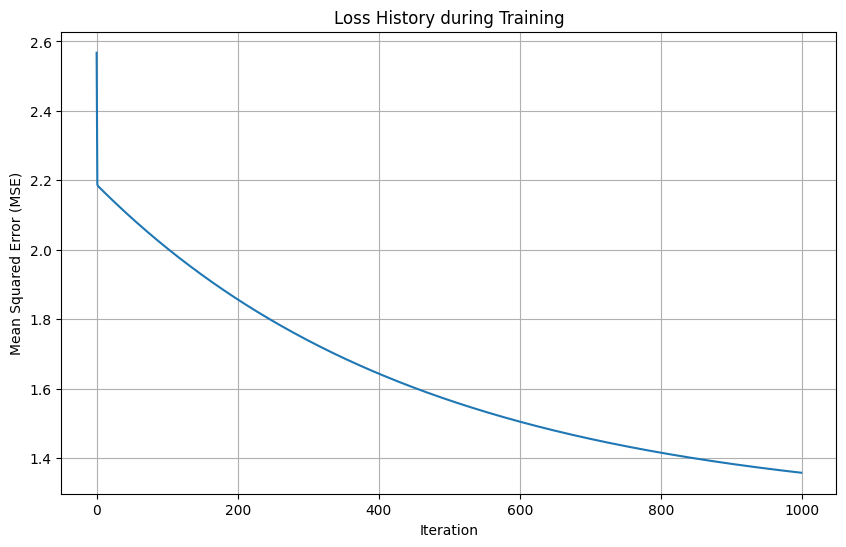

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(range(len(loss_history)), loss_history)
plt.title('Loss History during Training')
plt.xlabel('Iteration')
plt.ylabel('Mean Squared Error (MSE)')
plt.grid(True)
plt.show()

### 9. Visualize the Regression Line

Finally, I will plot the original data points along with the regression line predicted by our trained model. This visual representation will help us assess the model's fit to the data.

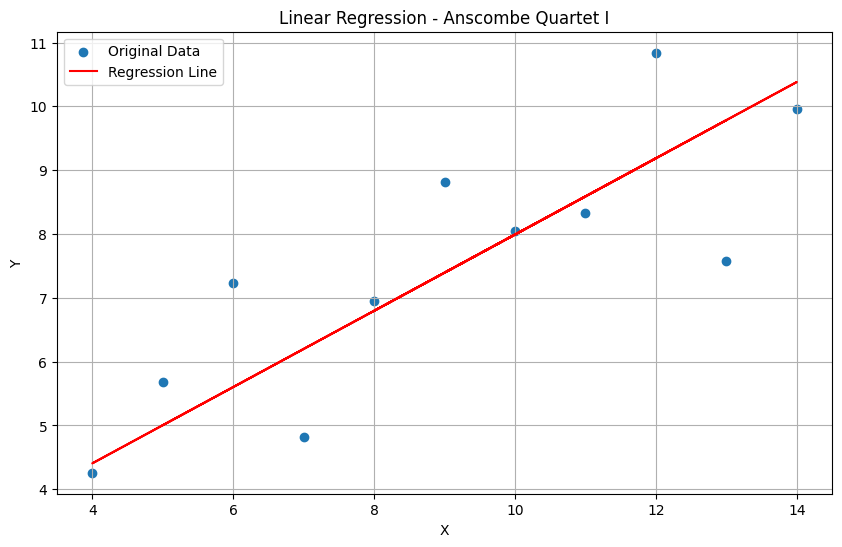

In [12]:
# Generate predictions using the trained model
y_pred_final = predict(X, w_trained, b_trained)

plt.figure(figsize=(10, 6))
plt.scatter(X, y, label='Original Data')
plt.plot(X, y_pred_final, color='red', label='Regression Line')
plt.title('Linear Regression - Anscombe Quartet I')
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()
plt.grid(True)
plt.show()

### 10. Linear Regression with Scikit-learn

Now, let's implement the same linear regression using scikit-learn to compare its performance, including training time, testing accuracy (R-squared), and Mean Squared Error (MSE).

In [13]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import time

print("Scikit-learn modules imported.")

Scikit-learn modules imported.


Given the very small dataset (11 points), a robust train-test split for evaluating 'testing accuracy' is challenging. For demonstration purposes, we will perform a small split. Ideally, for such small datasets, cross-validation would be more appropriate, or evaluation on the entire dataset for direct comparison with the custom model.

In [14]:
# Split the data into training and testing sets
# For simplicity with a very small dataset, we'll use a small test size
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}, y_test shape: {y_test.shape}")

X_train shape: (8, 1), y_train shape: (8, 1)
X_test shape: (3, 1), y_test shape: (3, 1)


In [15]:
# Initialize and train the scikit-learn Linear Regression model
model_sklearn = LinearRegression()

start_time = time.time()
model_sklearn.fit(X_train, y_train)
end_time = time.time()

sklearn_training_time = end_time - start_time

print(f"Scikit-learn model trained in {sklearn_training_time:.6f} seconds.")
print(f"Scikit-learn Learned Weight (w): {model_sklearn.coef_[0][0]:.4f}")
print(f"Scikit-learn Learned Bias (b): {model_sklearn.intercept_[0]:.4f}")

Scikit-learn model trained in 0.018951 seconds.
Scikit-learn Learned Weight (w): 0.4699
Scikit-learn Learned Bias (b): 3.4668


In [16]:
# Make predictions on the test set
y_pred_sklearn = model_sklearn.predict(X_test)

# Calculate MSE and R-squared
mse_sklearn = mean_squared_error(y_test, y_pred_sklearn)
r2_sklearn = r2_score(y_test, y_pred_sklearn)

print(f"Scikit-learn Test MSE: {mse_sklearn:.4f}")
print(f"Scikit-learn Test R-squared (Accuracy): {r2_sklearn:.4f}")

Scikit-learn Test MSE: 1.2576
Scikit-learn Test R-squared (Accuracy): 0.7204


### 11. Comparison

Let's compare the results from our custom gradient descent implementation and the scikit-learn `LinearRegression` model.

In [17]:
# For direct comparison, let's re-calculate custom model's MSE on the full dataset
y_pred_custom_full = predict(X, w_trained, b_trained)
mse_custom_full = mean_squared_error(y, y_pred_custom_full)

print("--- Custom Implementation Results ---")
print(f"Learned Weight (w): {w_trained[0][0]:.4f}")
print(f"Learned Bias (b): {b_trained:.4f}")
print(f"Final MSE (full dataset): {mse_custom_full:.4f}")
print("\n--- Scikit-learn Implementation Results ---")
print(f"Training Time: {sklearn_training_time:.6f} seconds")
print(f"Learned Weight (w): {model_sklearn.coef_[0][0]:.4f}")
print(f"Learned Bias (b): {model_sklearn.intercept_[0]:.4f}")
print(f"Test MSE: {mse_sklearn:.4f}")
print(f"Test R-squared (Accuracy): {r2_sklearn:.4f}")

--- Custom Implementation Results ---
Learned Weight (w): 0.5975
Learned Bias (b): 2.0165
Final MSE (full dataset): 1.3575

--- Scikit-learn Implementation Results ---
Training Time: 0.018951 seconds
Learned Weight (w): 0.4699
Learned Bias (b): 3.4668
Test MSE: 1.2576
Test R-squared (Accuracy): 0.7204


### 12. Visualizing Model Performance

#### Regression Line (Scikit-learn)

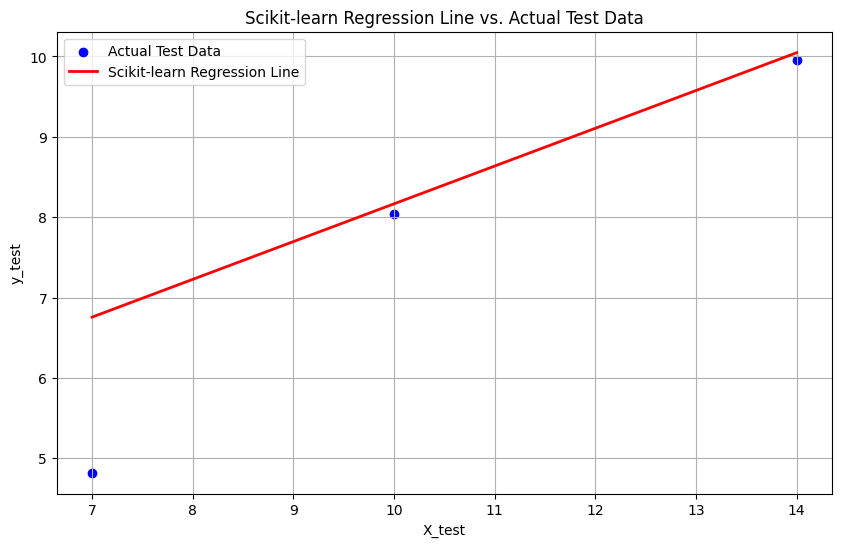

In [18]:
plt.figure(figsize=(10, 6))
plt.scatter(X_test, y_test, color='blue', label='Actual Test Data')
plt.plot(X_test, y_pred_sklearn, color='red', linewidth=2, label='Scikit-learn Regression Line')
plt.title('Scikit-learn Regression Line vs. Actual Test Data')
plt.xlabel('X_test')
plt.ylabel('y_test')
plt.legend()
plt.grid(True)
plt.show()

#### Actual vs. Predicted Values Plot

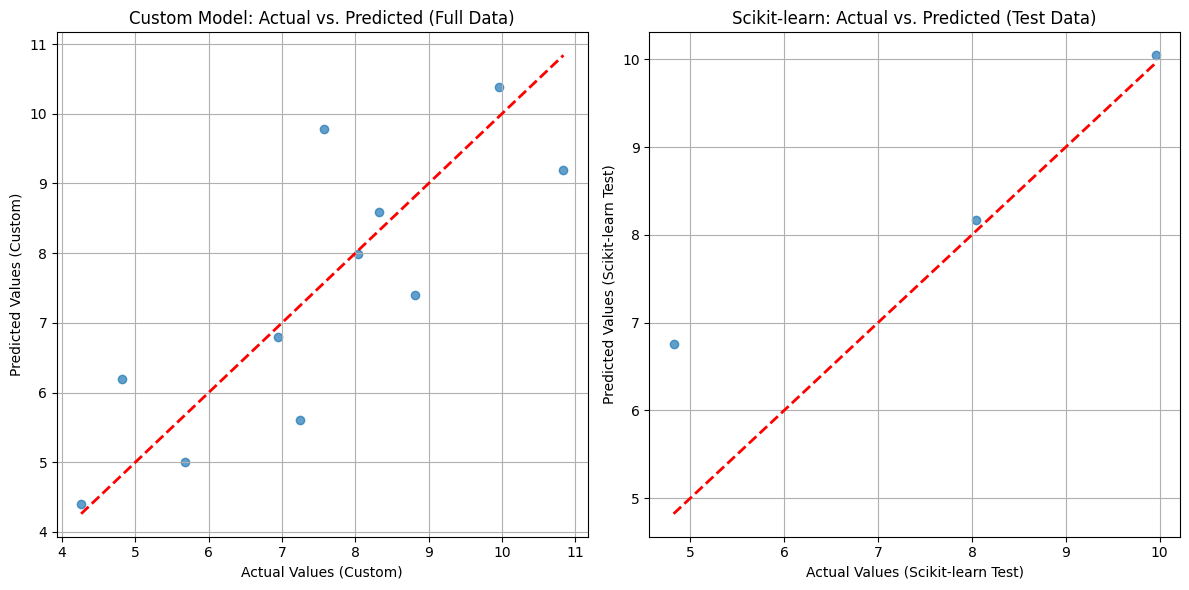

In [19]:
plt.figure(figsize=(12, 6))

# Custom Model Actual vs. Predicted (full dataset)
plt.subplot(1, 2, 1)
plt.scatter(y, y_pred_custom_full, alpha=0.7)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2)
plt.xlabel('Actual Values (Custom)')
plt.ylabel('Predicted Values (Custom)')
plt.title('Custom Model: Actual vs. Predicted (Full Data)')
plt.grid(True)

# Scikit-learn Model Actual vs. Predicted (test dataset)
plt.subplot(1, 2, 2)
plt.scatter(y_test, y_pred_sklearn, alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Values (Scikit-learn Test)')
plt.ylabel('Predicted Values (Scikit-learn Test)')
plt.title('Scikit-learn: Actual vs. Predicted (Test Data)')
plt.grid(True)

plt.tight_layout()
plt.show()

#### Residual Plot

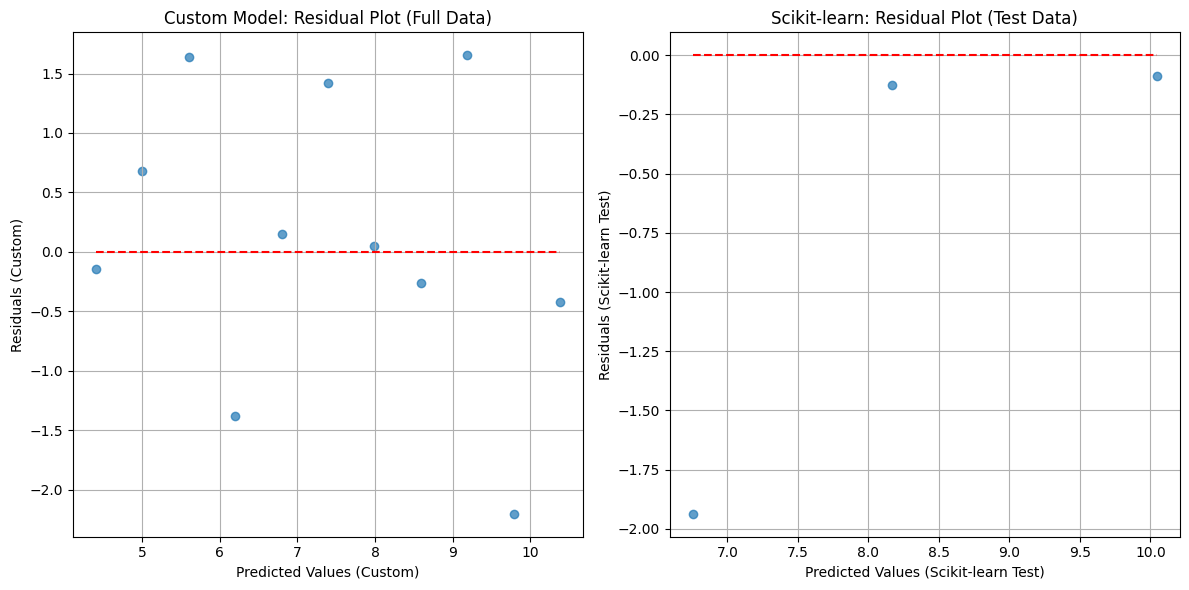

In [20]:
# Calculate residuals for both models
residuals_custom = y - y_pred_custom_full
residuals_sklearn = y_test - y_pred_sklearn

plt.figure(figsize=(12, 6))

# Custom Model Residual Plot
plt.subplot(1, 2, 1)
plt.scatter(y_pred_custom_full, residuals_custom, alpha=0.7)
plt.hlines(y=0, xmin=y_pred_custom_full.min(), xmax=y_pred_custom_full.max(), color='red', linestyle='--')
plt.xlabel('Predicted Values (Custom)')
plt.ylabel('Residuals (Custom)')
plt.title('Custom Model: Residual Plot (Full Data)')
plt.grid(True)

# Scikit-learn Model Residual Plot
plt.subplot(1, 2, 2)
plt.scatter(y_pred_sklearn, residuals_sklearn, alpha=0.7)
plt.hlines(y=0, xmin=y_pred_sklearn.min(), xmax=y_pred_sklearn.max(), color='red', linestyle='--')
plt.xlabel('Predicted Values (Scikit-learn Test)')
plt.ylabel('Residuals (Scikit-learn Test)')
plt.title('Scikit-learn: Residual Plot (Test Data)')
plt.grid(True)

plt.tight_layout()
plt.show()

### Interpretation of Visualization Results

**Regression Line Plot (Scikit-learn):**
This plot visually represents how well the scikit-learn model's linear regression line fits the actual data points from the test set. A good fit would show data points clustered closely around the line.

**Actual vs. Predicted Values Plots:**
For both the custom and scikit-learn models, these plots show the relationship between the true target values and the values predicted by the models. Ideally, points should fall along the red dashed 45-degree line, indicating perfect predictions. Deviations from this line represent prediction errors.

*   **Custom Model:** We observe how well the custom gradient descent model's predictions align with the actual values on the *full training dataset*.
*   **Scikit-learn Model:** This plot shows the performance of the scikit-learn model on the *test dataset*. It helps us see if the model generalizes well to unseen data.

**Residual Plots:**
Residual plots are crucial for checking the assumptions of linear regression and identifying patterns in the errors (residuals).

*   **Ideal Residual Plot:** For a good linear regression model, residuals should be randomly scattered around the horizontal line at zero, with no clear pattern. This indicates that the model has captured most of the linear relationship in the data.

*   **Observations:**
    *   If residuals show a discernible pattern (e.g., a curve, a funnel shape), it suggests that the linear model might not be appropriate, or there might be heteroscedasticity (non-constant variance of errors).
    *   Outliers in the residual plot indicate data points where the model performed particularly poorly.

Given the very small size of the 'dataset I' from Anscombe's Quartet, these plots might show specific patterns that reflect the nature of this dataset (designed to highlight limitations of simply looking at summary statistics). We can see how closely both implementations align with the underlying linear trend of the data.

### 13. Implementing Polynomial Regression (Degree 2)

First, we will transform our feature `X` into polynomial features using `PolynomialFeatures` from scikit-learn. We'll start with a degree of 2.

In [21]:
from sklearn.preprocessing import PolynomialFeatures

# Create polynomial features of degree 2
degree = 2
poly_features = PolynomialFeatures(degree=degree)
X_poly = poly_features.fit_transform(X)

print(f"Original X shape: {X.shape}")
print(f"Transformed X_poly shape (degree {degree}): {X_poly.shape}")
print("First 5 rows of X_poly:\n", X_poly[:5])

Original X shape: (11, 1)
Transformed X_poly shape (degree 2): (11, 3)
First 5 rows of X_poly:
 [[  1.  10. 100.]
 [  1.   8.  64.]
 [  1.  13. 169.]
 [  1.   9.  81.]
 [  1.  11. 121.]]


Now, we will split the polynomial features into training and testing sets, train a `LinearRegression` model on these features, and evaluate its performance.

In [22]:
# Split the polynomial data into training and testing sets
X_train_poly, X_test_poly, y_train_poly, y_test_poly = train_test_split(X_poly, y, test_size=0.2, random_state=42)

print(f"X_train_poly shape: {X_train_poly.shape}, y_train_poly shape: {y_train_poly.shape}")
print(f"X_test_poly shape: {X_test_poly.shape}, y_test_poly shape: {y_test_poly.shape}")

# Initialize and train the scikit-learn Linear Regression model on polynomial features
model_poly = LinearRegression()

start_time_poly = time.time()
model_poly.fit(X_train_poly, y_train_poly)
end_time_poly = time.time()

poly_training_time = end_time_poly - start_time_poly

print(f"\nPolynomial Regression model trained in {poly_training_time:.6f} seconds.")
print(f"Polynomial Regression Learned Coefficients (w): {model_poly.coef_[0]}")
print(f"Polynomial Regression Learned Bias (b): {model_poly.intercept_[0]:.4f}")

X_train_poly shape: (8, 3), y_train_poly shape: (8, 1)
X_test_poly shape: (3, 3), y_test_poly shape: (3, 1)

Polynomial Regression model trained in 0.017495 seconds.
Polynomial Regression Learned Coefficients (w): [ 0.          1.96791535 -0.08811644]
Polynomial Regression Learned Bias (b): -2.0405


In [23]:
# Make predictions on the polynomial test set
y_pred_poly = model_poly.predict(X_test_poly)

# Calculate MSE and R-squared for polynomial regression
mse_poly = mean_squared_error(y_test_poly, y_pred_poly)
r2_poly = r2_score(y_test_poly, y_pred_poly)

print(f"Polynomial Regression Test MSE: {mse_poly:.4f}")
print(f"Polynomial Regression Test R-squared (Accuracy): {r2_poly:.4f}")

Polynomial Regression Test MSE: 3.4417
Polynomial Regression Test R-squared (Accuracy): 0.2347


### 14. Comparison with Polynomial Regression

In [24]:
print("--- Custom Linear Regression Results ---")
print(f"Learned Weight (w): {w_trained[0][0]:.4f}")
print(f"Learned Bias (b): {b_trained:.4f}")
print(f"Final MSE (full dataset): {mse_custom_full:.4f}")

print("\n--- Scikit-learn Linear Regression Results ---")
print(f"Training Time: {sklearn_training_time:.6f} seconds")
print(f"Learned Weight (w): {model_sklearn.coef_[0][0]:.4f}")
print(f"Learned Bias (b): {model_sklearn.intercept_[0]:.4f}")
print(f"Test MSE: {mse_sklearn:.4f}")
print(f"Test R-squared (Accuracy): {r2_sklearn:.4f}")

print("\n--- Scikit-learn Polynomial Regression (Degree 2) Results ---")
print(f"Training Time: {poly_training_time:.6f} seconds")
print(f"Learned Coefficients (w): {model_poly.coef_[0]}")
print(f"Learned Bias (b): {model_poly.intercept_[0]:.4f}")
print(f"Test MSE: {mse_poly:.4f}")
print(f"Test R-squared (Accuracy): {r2_poly:.4f}")

--- Custom Linear Regression Results ---
Learned Weight (w): 0.5975
Learned Bias (b): 2.0165
Final MSE (full dataset): 1.3575

--- Scikit-learn Linear Regression Results ---
Training Time: 0.018951 seconds
Learned Weight (w): 0.4699
Learned Bias (b): 3.4668
Test MSE: 1.2576
Test R-squared (Accuracy): 0.7204

--- Scikit-learn Polynomial Regression (Degree 2) Results ---
Training Time: 0.017495 seconds
Learned Coefficients (w): [ 0.          1.96791535 -0.08811644]
Learned Bias (b): -2.0405
Test MSE: 3.4417
Test R-squared (Accuracy): 0.2347


### 15. Visualizing Polynomial Regression Performance

Let's visualize the polynomial regression curve and its actual vs. predicted values and residual plots.

#### Polynomial Regression Curve

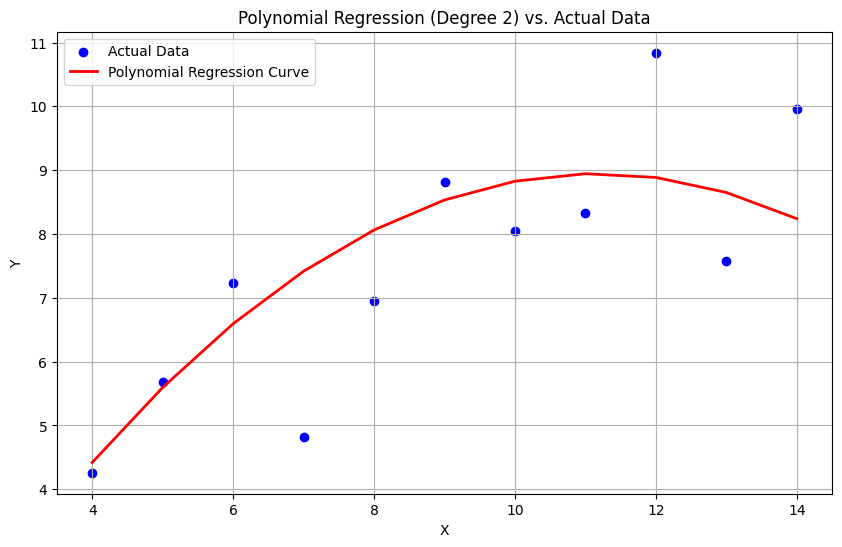

In [25]:
# Sort the X values to plot a smooth curve
X_sorted = np.sort(X, axis=0)
X_sorted_poly = poly_features.transform(X_sorted)
y_pred_poly_sorted = model_poly.predict(X_sorted_poly)

plt.figure(figsize=(10, 6))
plt.scatter(X, y, color='blue', label='Actual Data')
plt.plot(X_sorted, y_pred_poly_sorted, color='red', linewidth=2, label='Polynomial Regression Curve')
plt.title(f'Polynomial Regression (Degree {degree}) vs. Actual Data')
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()
plt.grid(True)
plt.show()

#### Actual vs. Predicted Values Plot (Polynomial Regression)

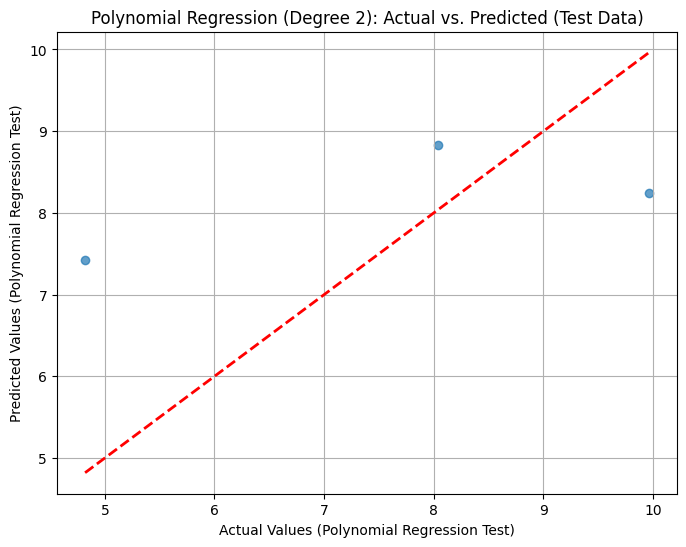

In [26]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test_poly, y_pred_poly, alpha=0.7)
plt.plot([y_test_poly.min(), y_test_poly.max()], [y_test_poly.min(), y_test_poly.max()], 'r--', lw=2)
plt.xlabel('Actual Values (Polynomial Regression Test)')
plt.ylabel('Predicted Values (Polynomial Regression Test)')
plt.title(f'Polynomial Regression (Degree {degree}): Actual vs. Predicted (Test Data)')
plt.grid(True)
plt.show()

#### Residual Plot (Polynomial Regression)

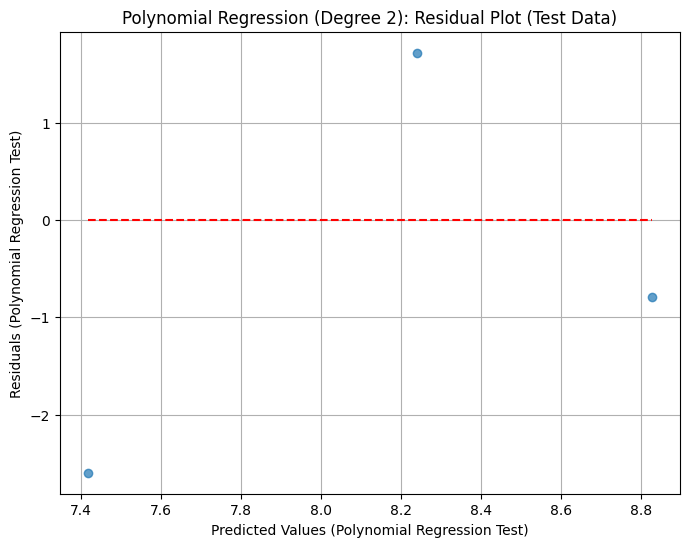

In [27]:
residuals_poly = y_test_poly - y_pred_poly

plt.figure(figsize=(8, 6))
plt.scatter(y_pred_poly, residuals_poly, alpha=0.7)
plt.hlines(y=0, xmin=y_pred_poly.min(), xmax=y_pred_poly.max(), color='red', linestyle='--')
plt.xlabel('Predicted Values (Polynomial Regression Test)')
plt.ylabel('Residuals (Polynomial Regression Test)')
plt.title(f'Polynomial Regression (Degree {degree}): Residual Plot (Test Data)')
plt.grid(True)
plt.show()

### 16. Interpretation of Polynomial Regression Results

**Comparison of Metrics:**
By comparing the MSE and R-squared values for custom linear regression, scikit-learn linear regression, and polynomial regression, we can assess which model provides a better fit to the data. A lower MSE and higher R-squared generally indicate better performance.

**Visualizations:**
*   **Polynomial Regression Curve:** This plot shows the non-linear curve fitted by the polynomial regression model. For datasets where the relationship between X and Y is not strictly linear, a polynomial curve might capture the trend more accurately.
*   **Actual vs. Predicted Values:** Similar to linear regression, this plot for polynomial regression helps visualize the accuracy of predictions. Points closer to the 45-degree line indicate better predictive power.
*   **Residual Plot:** The residual plot for polynomial regression should ideally show no discernible pattern, with residuals randomly scattered around zero. If a pattern exists, it suggests that even the polynomial of the chosen degree might not be capturing the underlying relationship adequately, or higher-degree polynomials might be needed.

### 17. Creating a Machine Learning Pipeline (Polynomial Regression)

A machine learning pipeline helps to automate and streamline the workflow, combining multiple steps (like feature engineering and model training) into a single object. We will build a pipeline for our polynomial regression model.

In [28]:
from sklearn.pipeline import Pipeline

# Define the steps for the pipeline
# Step 1: Polynomial Features transformation
# Step 2: Linear Regression model

pipeline = Pipeline([
    ('poly_features', PolynomialFeatures(degree=degree)),
    ('linear_regression', LinearRegression())
])

print("Pipeline created successfully:")
print(pipeline)

Pipeline created successfully:
Pipeline(steps=[('poly_features', PolynomialFeatures()),
                ('linear_regression', LinearRegression())])


Now, let's train this pipeline using our original `X` and `y` data. The pipeline will automatically apply the polynomial transformation before training the linear regression model. We will then evaluate its performance on the test set.

In [29]:
# Split the original data into training and testing sets
# The pipeline will handle the polynomial transformation internally
X_train_pipe, X_test_pipe, y_train_pipe, y_test_pipe = train_test_split(X, y, test_size=0.2, random_state=42)

# Train the pipeline
start_time_pipe = time.time()
pipeline.fit(X_train_pipe, y_train_pipe)
end_time_pipe = time.time()

pipe_training_time = end_time_pipe - start_time_pipe

print(f"\nPipeline trained in {pipe_training_time:.6f} seconds.")

# Make predictions on the test set using the pipeline
y_pred_pipe = pipeline.predict(X_test_pipe)

# Evaluate the pipeline's performance
mse_pipe = mean_squared_error(y_test_pipe, y_pred_pipe)
r2_pipe = r2_score(y_test_pipe, y_pred_pipe)

print(f"Pipeline Test MSE: {mse_pipe:.4f}")
print(f"Pipeline Test R-squared (Accuracy): {r2_pipe:.4f}")


Pipeline trained in 0.027125 seconds.
Pipeline Test MSE: 3.4417
Pipeline Test R-squared (Accuracy): 0.2347


### 18. Final Comparison with Pipeline Results

In [30]:
print("--- Custom Linear Regression Results ---")
print(f"Learned Weight (w): {w_trained[0][0]:.4f}")
print(f"Learned Bias (b): {b_trained:.4f}")
print(f"Final MSE (full dataset): {mse_custom_full:.4f}")

print("\n--- Scikit-learn Linear Regression Results ---")
print(f"Training Time: {sklearn_training_time:.6f} seconds")
print(f"Learned Weight (w): {model_sklearn.coef_[0][0]:.4f}")
print(f"Learned Bias (b): {model_sklearn.intercept_[0]:.4f}")
print(f"Test MSE: {mse_sklearn:.4f}")
print(f"Test R-squared (Accuracy): {r2_sklearn:.4f}")

print("\n--- Scikit-learn Polynomial Regression (Degree 2) Results ---")
print(f"Training Time: {poly_training_time:.6f} seconds")
# Extract coefficients from the linear regression step within the pipeline
poly_lin_reg_model = pipeline.named_steps['linear_regression']
print(f"Learned Coefficients (w): {poly_lin_reg_model.coef_[0]}")
print(f"Learned Bias (b): {poly_lin_reg_model.intercept_[0]:.4f}")
print(f"Test MSE: {mse_poly:.4f}") # Re-using the previously calculated MSE for direct comparison
print(f"Test R-squared (Accuracy): {r2_poly:.4f}") # Re-using the previously calculated R2 for direct comparison

print("\n--- Scikit-learn Pipeline (Polynomial Regression Degree 2) Results ---")
print(f"Training Time: {pipe_training_time:.6f} seconds")
print(f"Pipeline Test MSE: {mse_pipe:.4f}")
print(f"Pipeline Test R-squared (Accuracy): {r2_pipe:.4f}")

--- Custom Linear Regression Results ---
Learned Weight (w): 0.5975
Learned Bias (b): 2.0165
Final MSE (full dataset): 1.3575

--- Scikit-learn Linear Regression Results ---
Training Time: 0.018951 seconds
Learned Weight (w): 0.4699
Learned Bias (b): 3.4668
Test MSE: 1.2576
Test R-squared (Accuracy): 0.7204

--- Scikit-learn Polynomial Regression (Degree 2) Results ---
Training Time: 0.017495 seconds
Learned Coefficients (w): [ 0.          1.96791535 -0.08811644]
Learned Bias (b): -2.0405
Test MSE: 3.4417
Test R-squared (Accuracy): 0.2347

--- Scikit-learn Pipeline (Polynomial Regression Degree 2) Results ---
Training Time: 0.027125 seconds
Pipeline Test MSE: 3.4417
Pipeline Test R-squared (Accuracy): 0.2347
